In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error


In [3]:
file_path = "/content/Housing.csv"
df = pd.read_csv("Housing.csv")

df.head()


,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
0,13300000,7420,4,2,3,yes,no,no,no,yes,2,yes,furnished
1,12250000,8960,4,4,4,yes,no,no,no,yes,3,no,furnished
2,12250000,9960,3,2,2,yes,no,yes,no,no,2,yes,semi-furnished
3,12215000,7500,4,2,2,yes,no,yes,no,yes,3,yes,furnished
4,11410000,7420,4,1,2,yes,yes,yes,no,yes,2,no,furnished


In [4]:
df = pd.get_dummies(df, drop_first=True)

df.head()


,price,area,bedrooms,bathrooms,stories,parking,mainroad_yes,guestroom_yes,basement_yes,hotwaterheating_yes,airconditioning_yes,prefarea_yes,furnishingstatus_semi-furnished,furnishingstatus_unfurnished
0,13300000,7420,4,2,3,2,True,False,False,False,True,True,False,False
1,12250000,8960,4,4,4,3,True,False,False,False,True,False,False,False
2,12250000,9960,3,2,2,2,True,False,True,False,False,True,True,False
3,12215000,7500,4,2,2,3,True,False,True,False,True,True,False,False
4,11410000,7420,4,1,2,2,True,True,True,False,True,False,False,False


In [5]:
X = df.drop('price', axis=1)
y = df['price']

print(X.shape)
print(y.shape)


(545, 13)
(545,)


In [6]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)


In [7]:
model = LinearRegression()
model.fit(X_train, y_train)


LinearRegression()

In [8]:
y_pred = model.predict(X_test)


In [9]:
mse = mean_squared_error(y_test, y_pred)
print("Mean Squared Error:", mse)


Mean Squared Error: 1754318687330.6643


In [10]:
B0 = model.intercept_
print("B0 (Intercept):", B0)


B0 (Intercept): 260032.35760741215


In [11]:
coefficients = model.coef_

equation = f"y = {B0:.2f}"
for i in range(len(coefficients)):
    equation += f" + ({coefficients[i]:.2f} * {X.columns[i]})"

print("Regression Equation:")
print(equation)


Regression Equation:
y = 260032.36 + (235.97 * area) + (76778.70 * bedrooms) + (1094444.79 * bathrooms) + (407476.59 * stories) + (224841.91 * parking) + (367919.95 * mainroad_yes) + (231610.04 * guestroom_yes) + (390251.18 * basement_yes) + (684649.89 * hotwaterheating_yes) + (791426.74 * airconditioning_yes) + (629890.57 * prefarea_yes) + (-126881.82 * furnishingstatus_semi-furnished) + (-413645.06 * furnishingstatus_unfurnished)


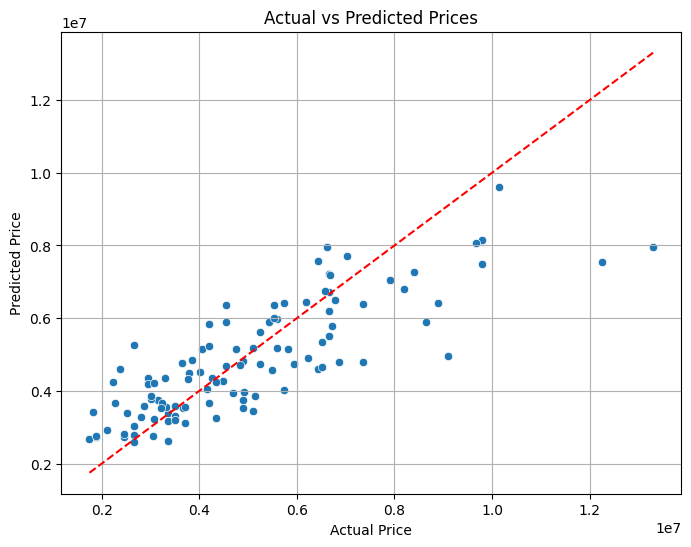

In [12]:
plt.figure(figsize=(8, 6))
sns.scatterplot(x=y_test, y=y_pred)
plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    'r--'
)
plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Actual vs Predicted Prices")
plt.grid(True)
plt.show()
